In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import pandas as pd

In [2]:
# read in
folder = Path('./output/classif_grid4b')
subfolders = ['t1','t2','t3']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

# get confs
config_names = dev['config'].unique().tolist()
confs = ConfigLookup(
    keys=['mlp','num_heads','aggregate'],
    configs=config_names,
    path=folder,
    save=True
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

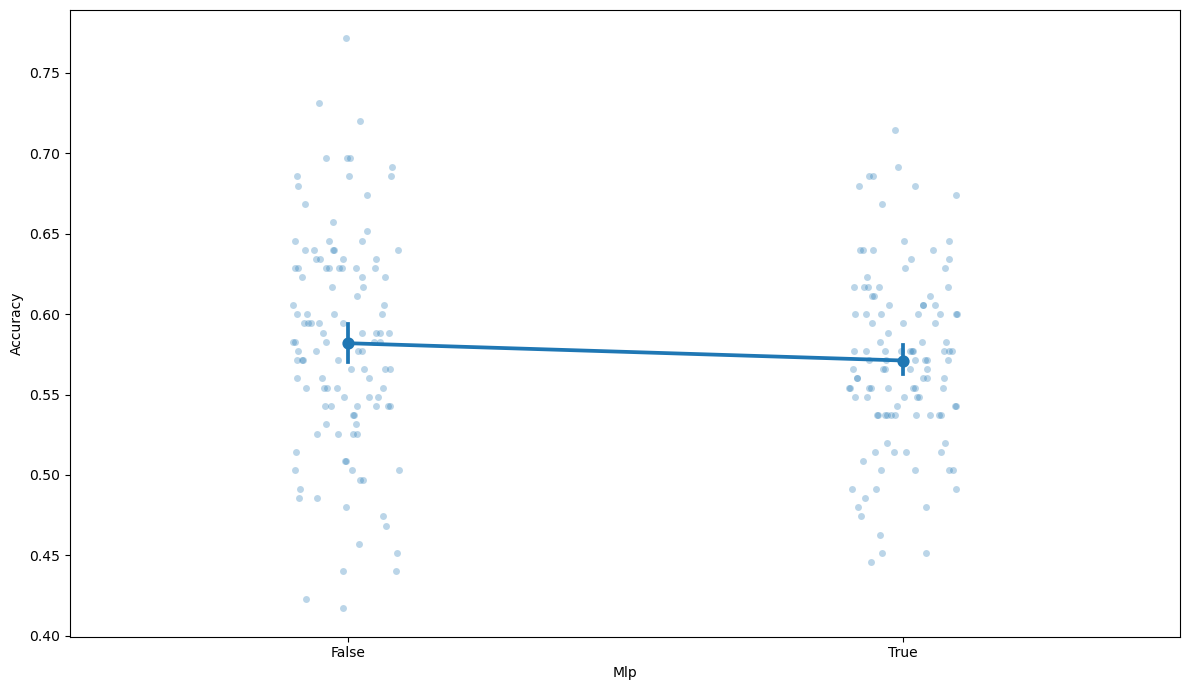

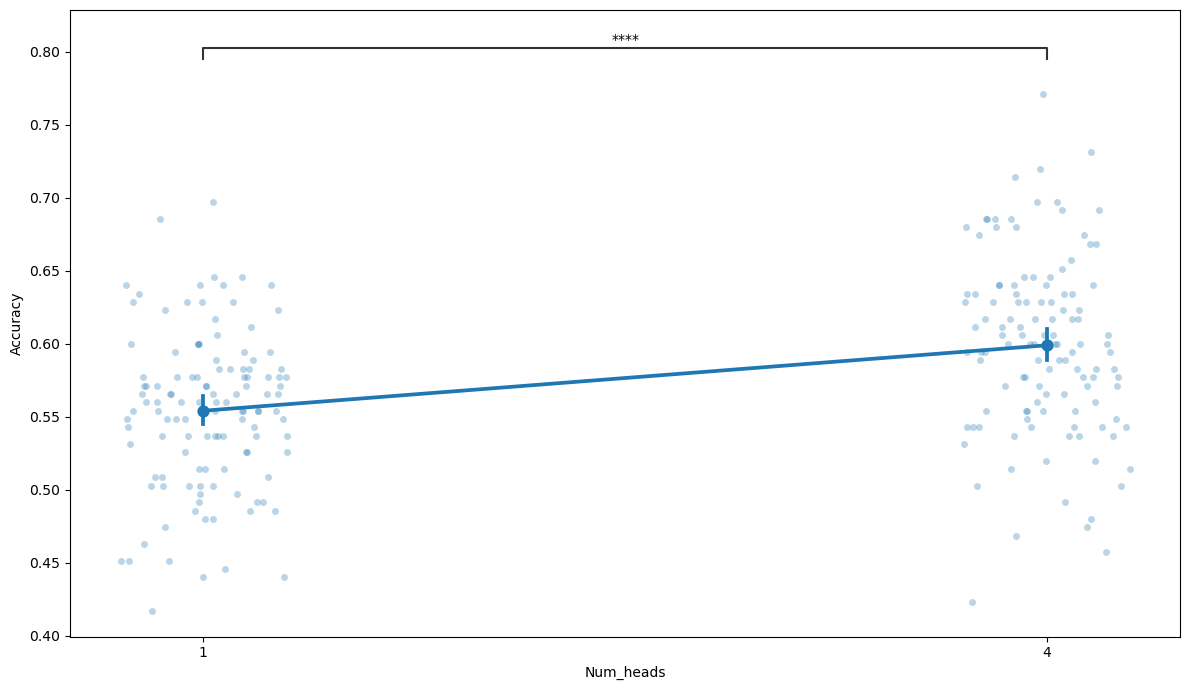

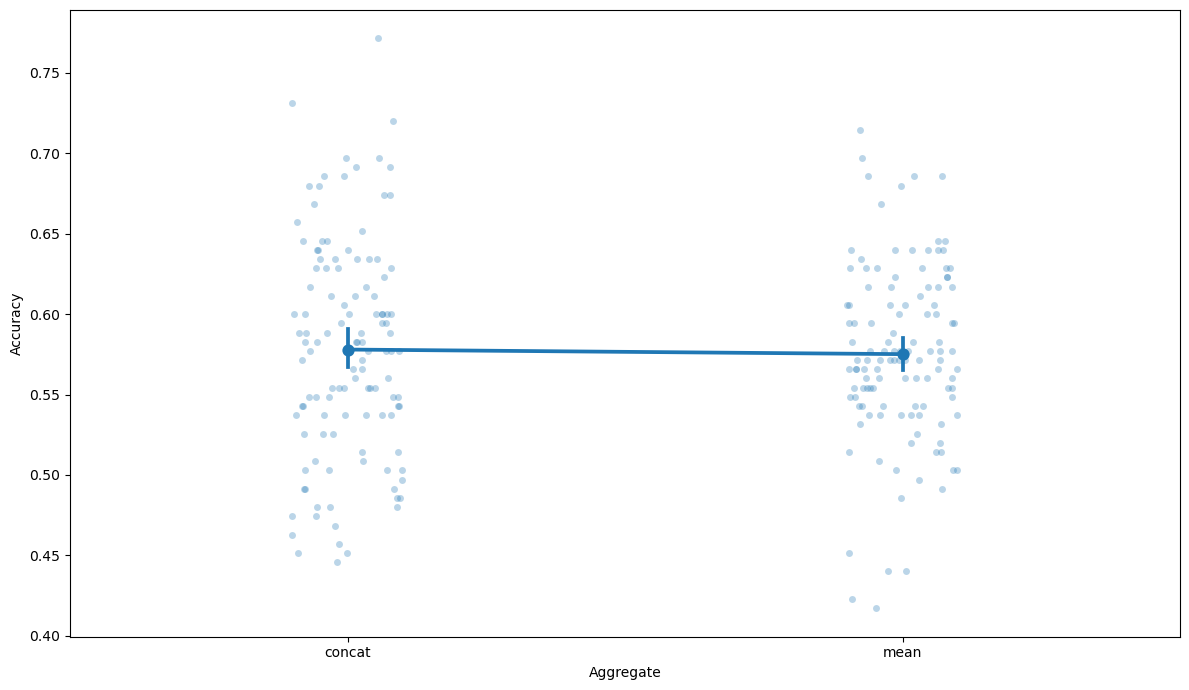

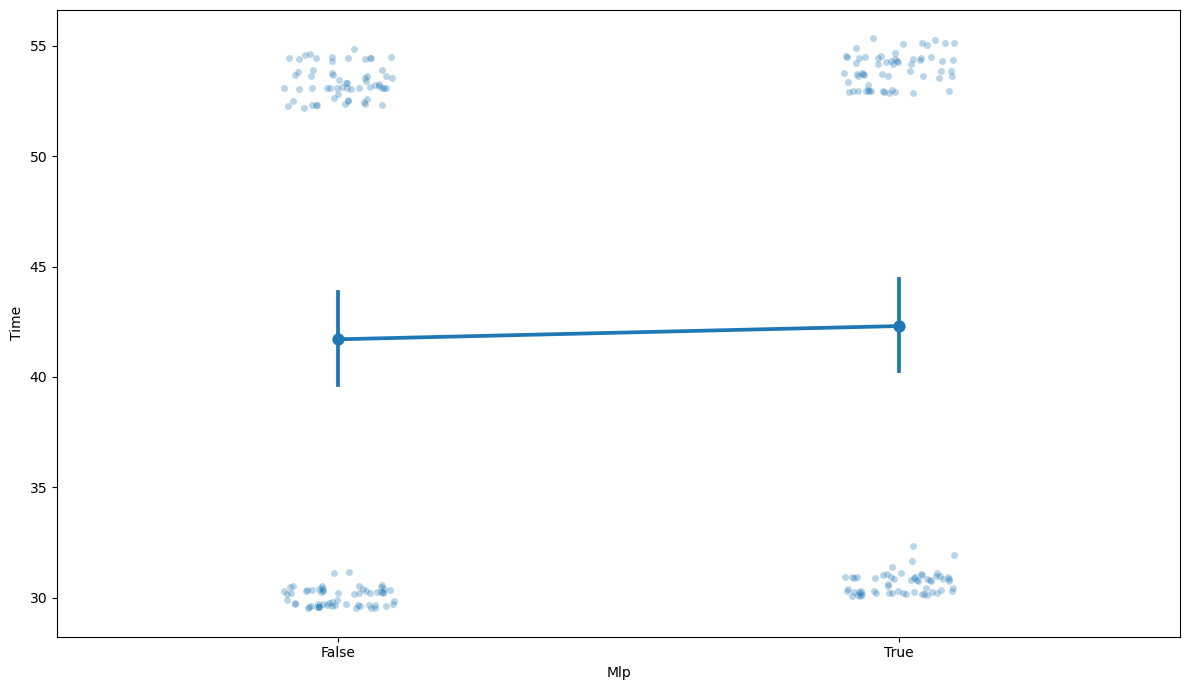

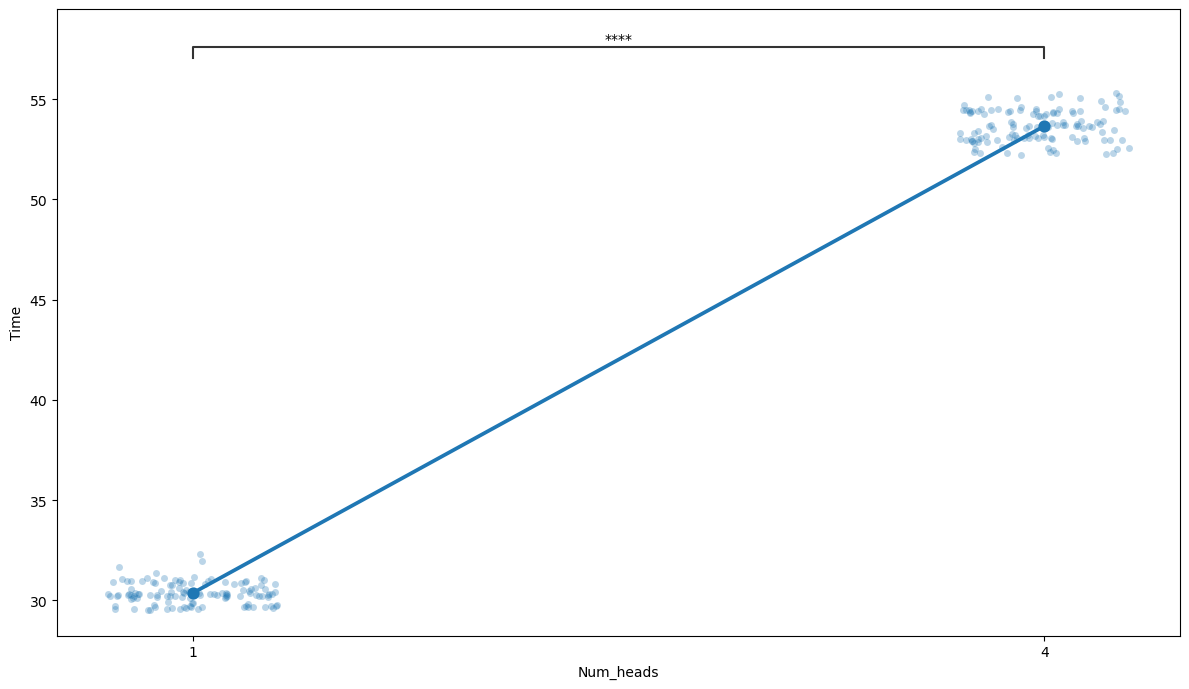

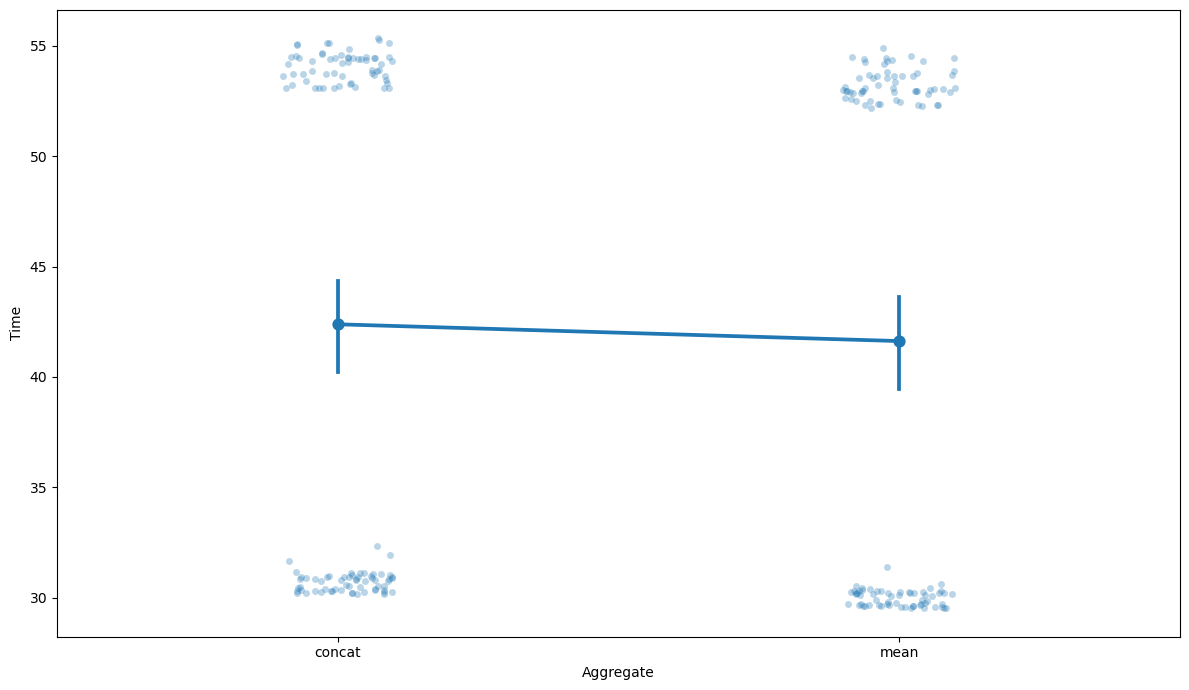

In [3]:
metric_x_point(
    df=test,
    cols=['mlp','num_heads','aggregate'],
    metrics=['accuracy','time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True
)

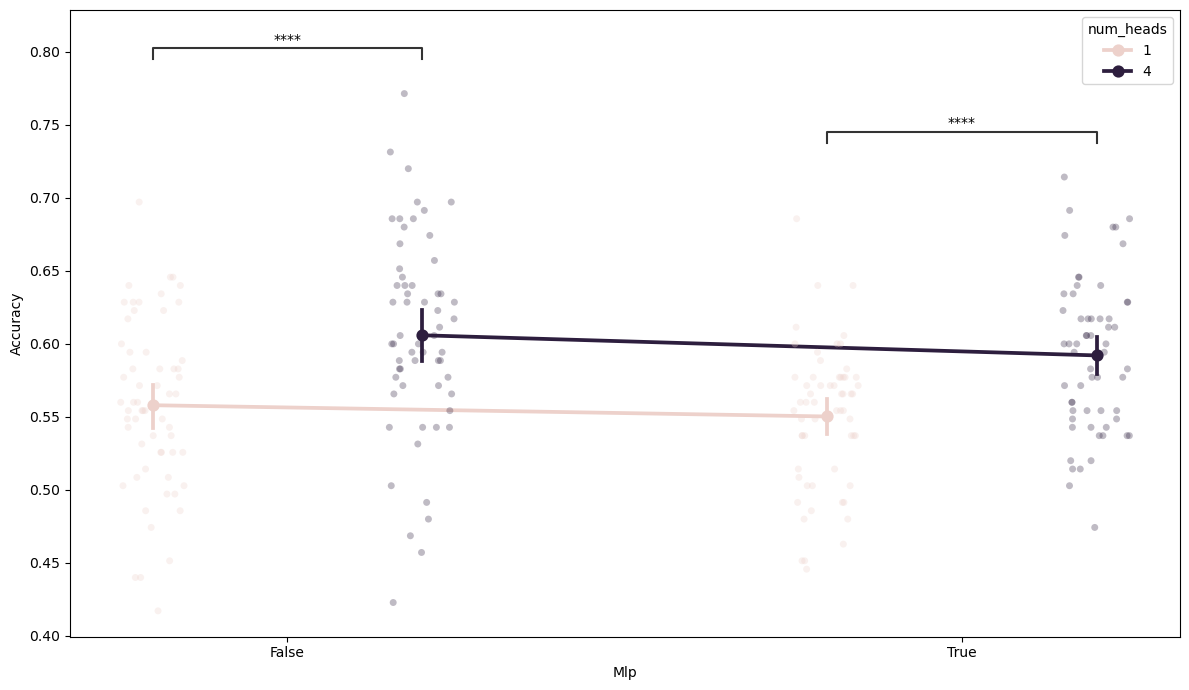

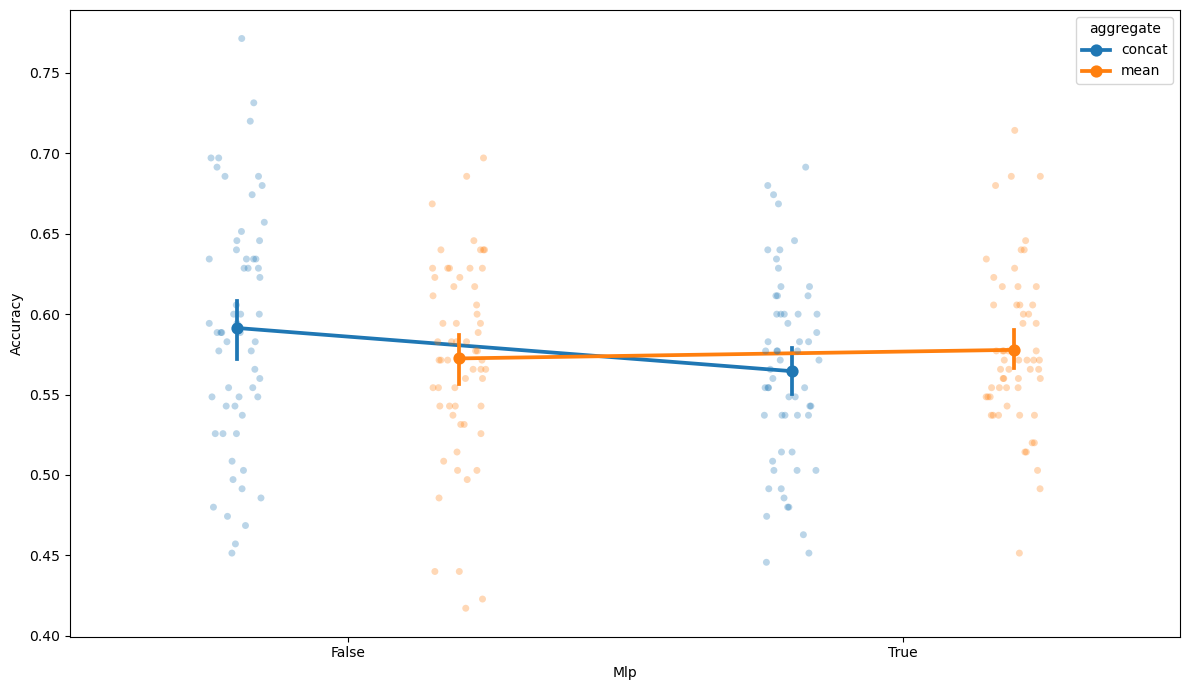

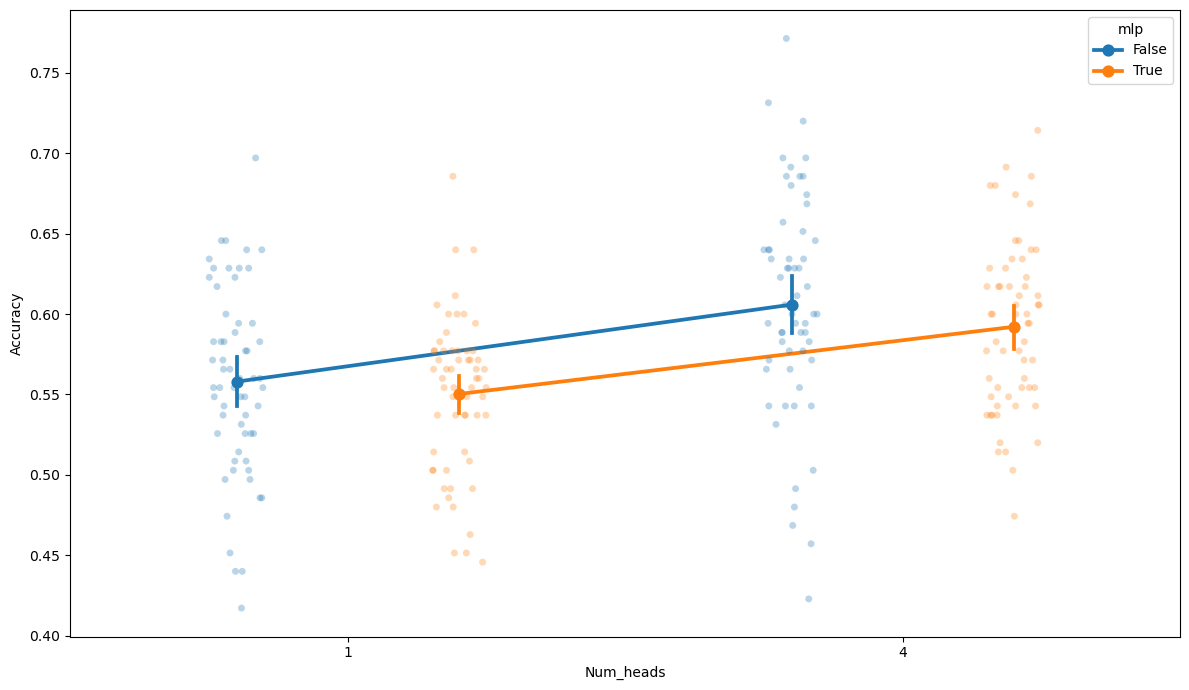

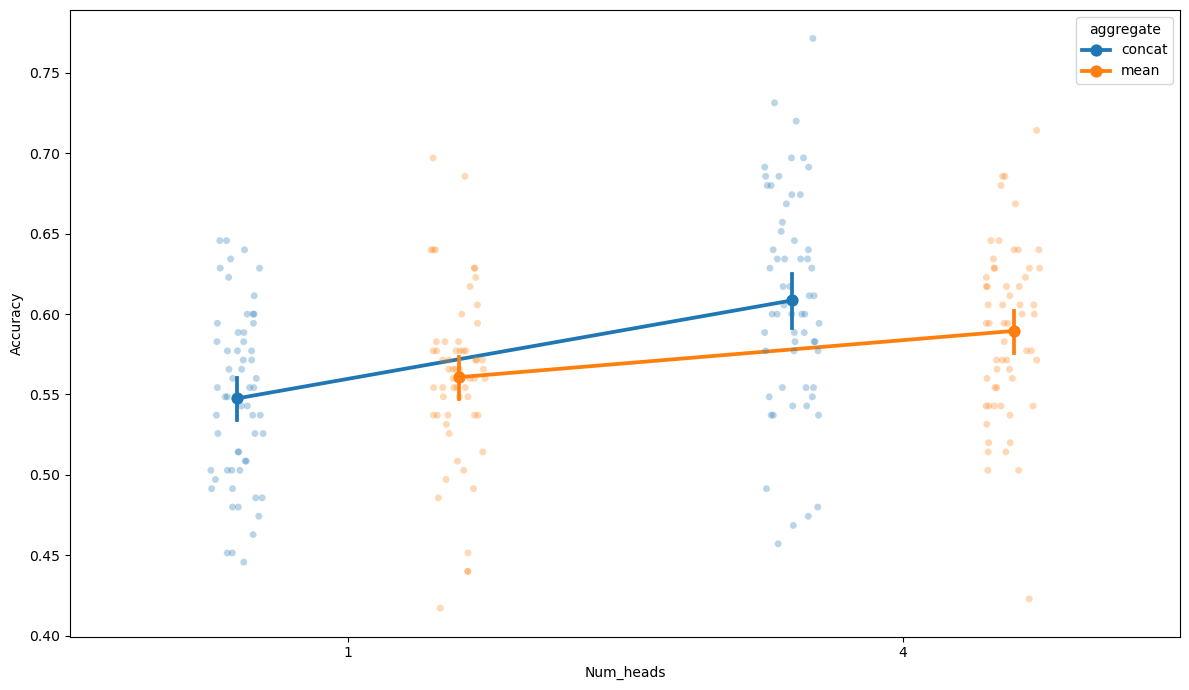

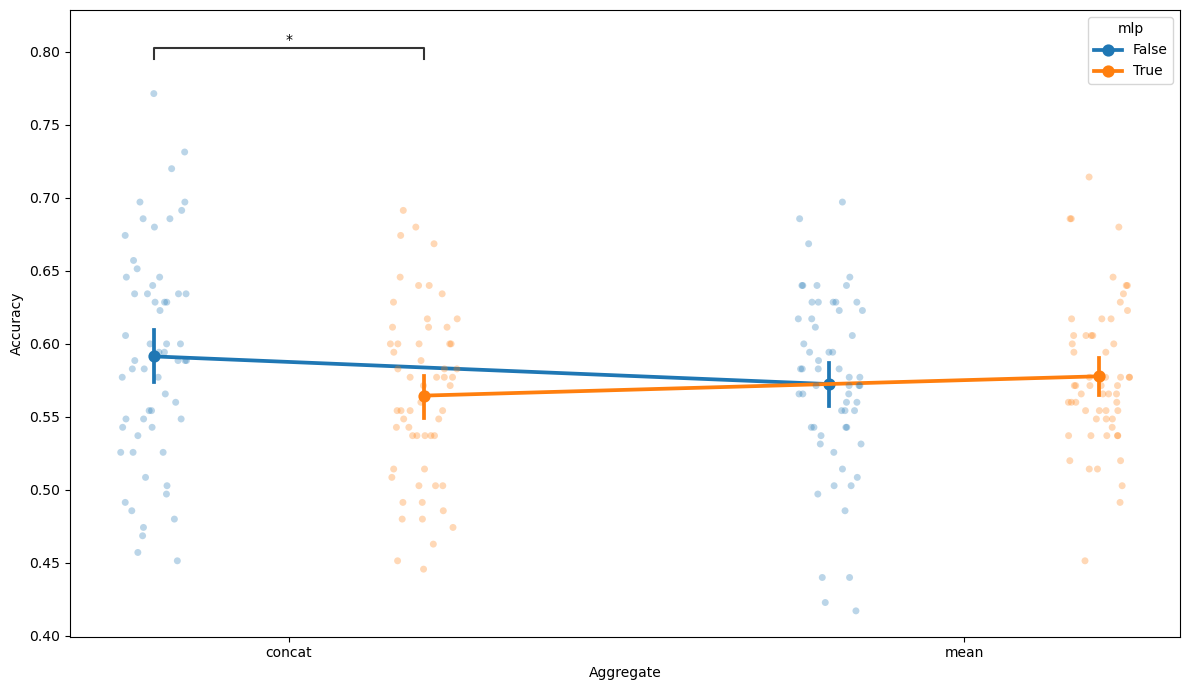

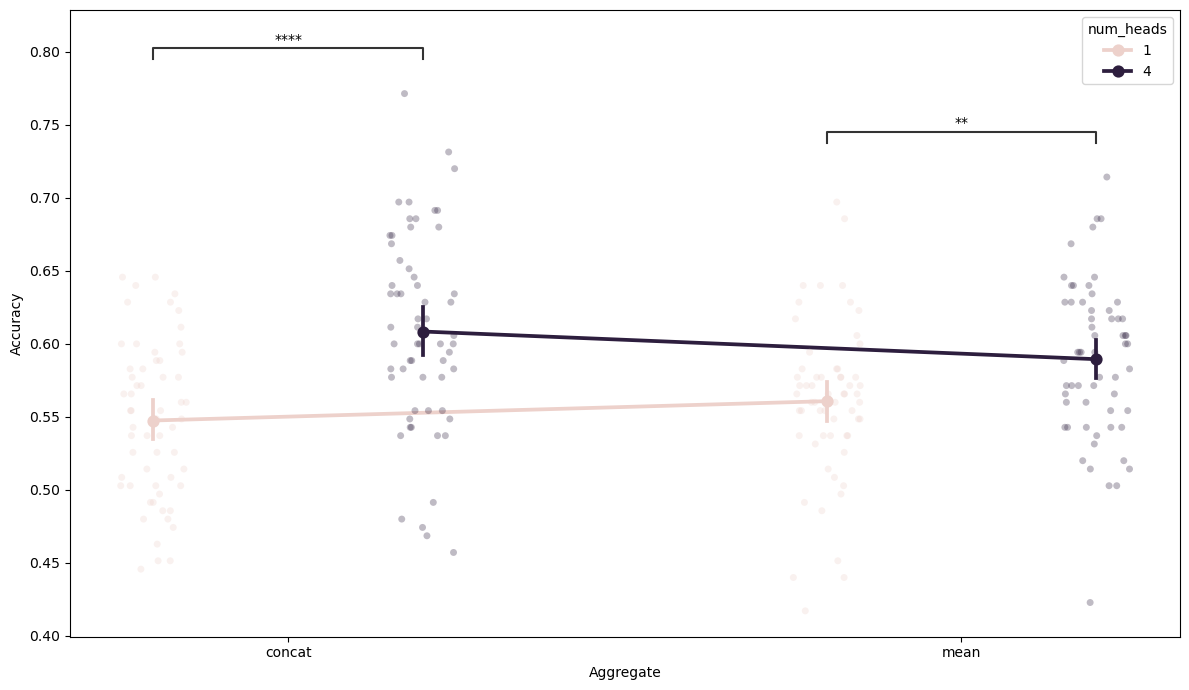

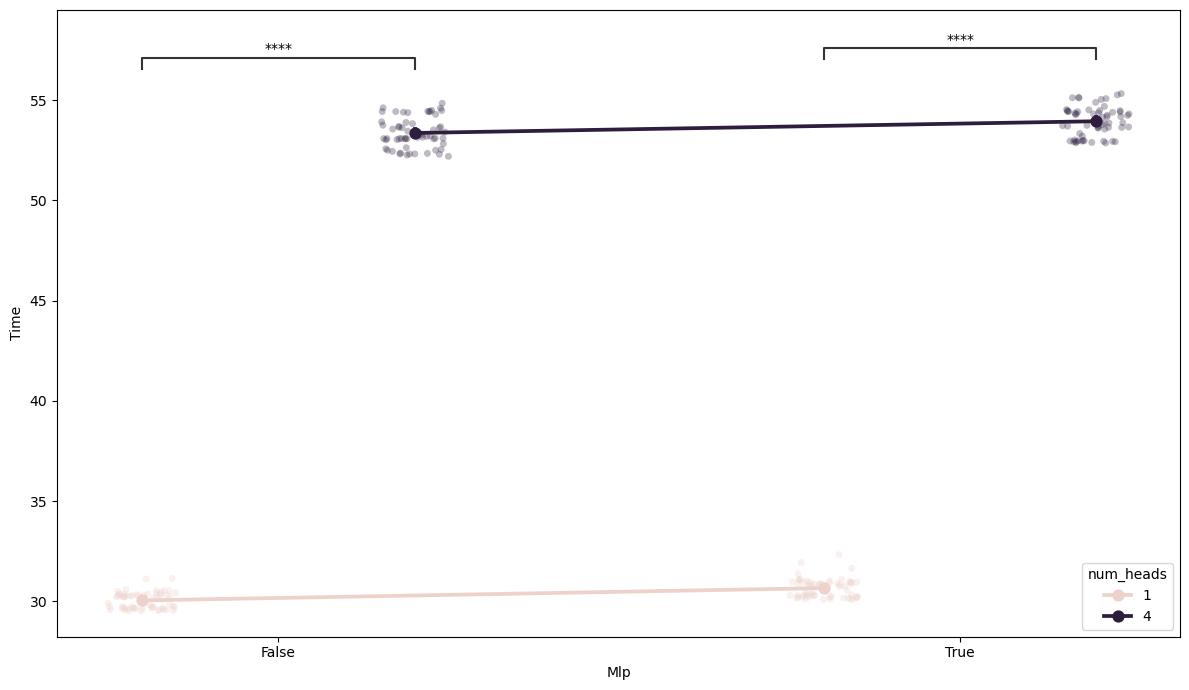

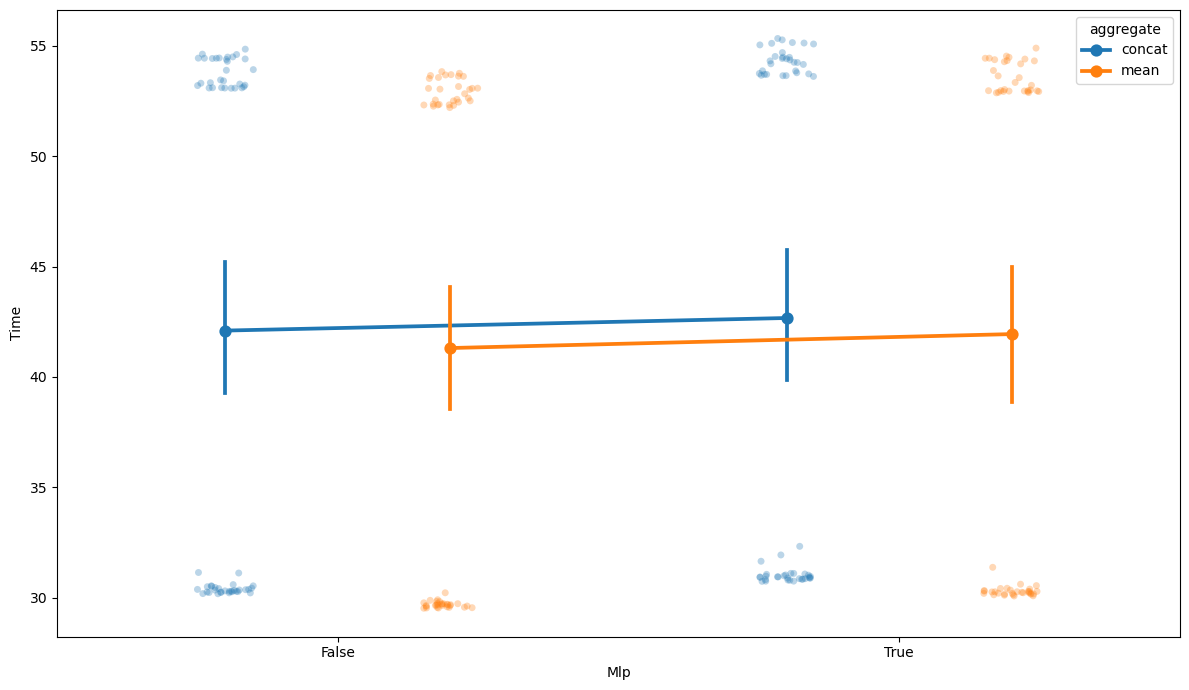

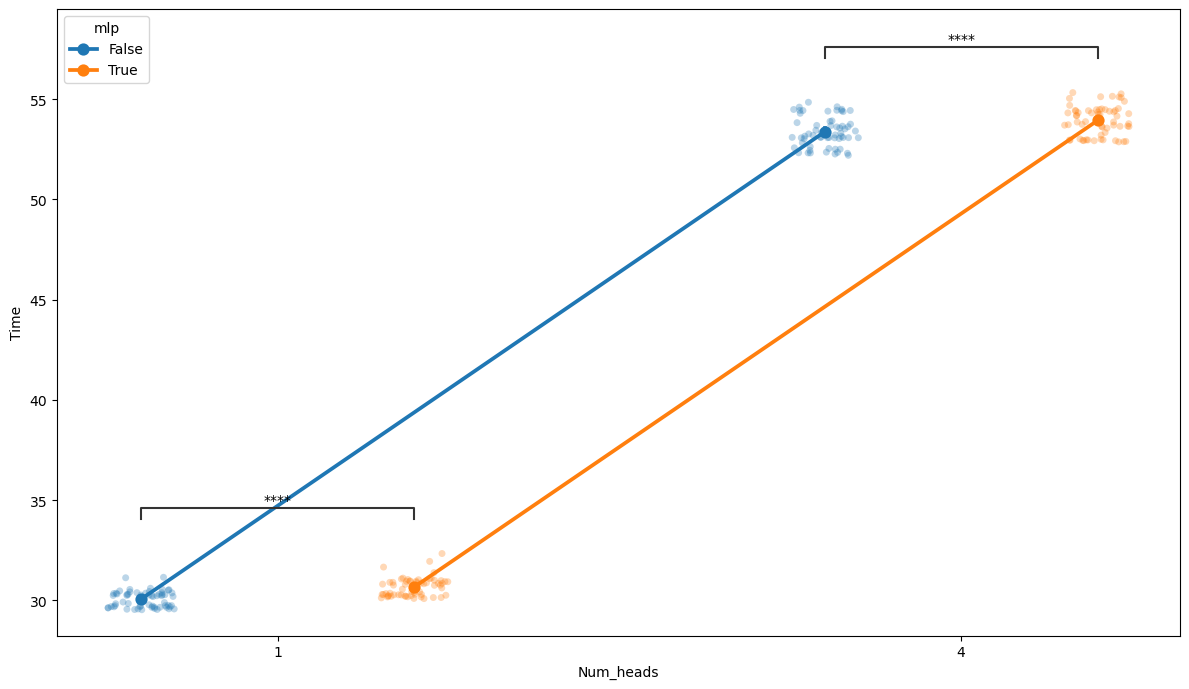

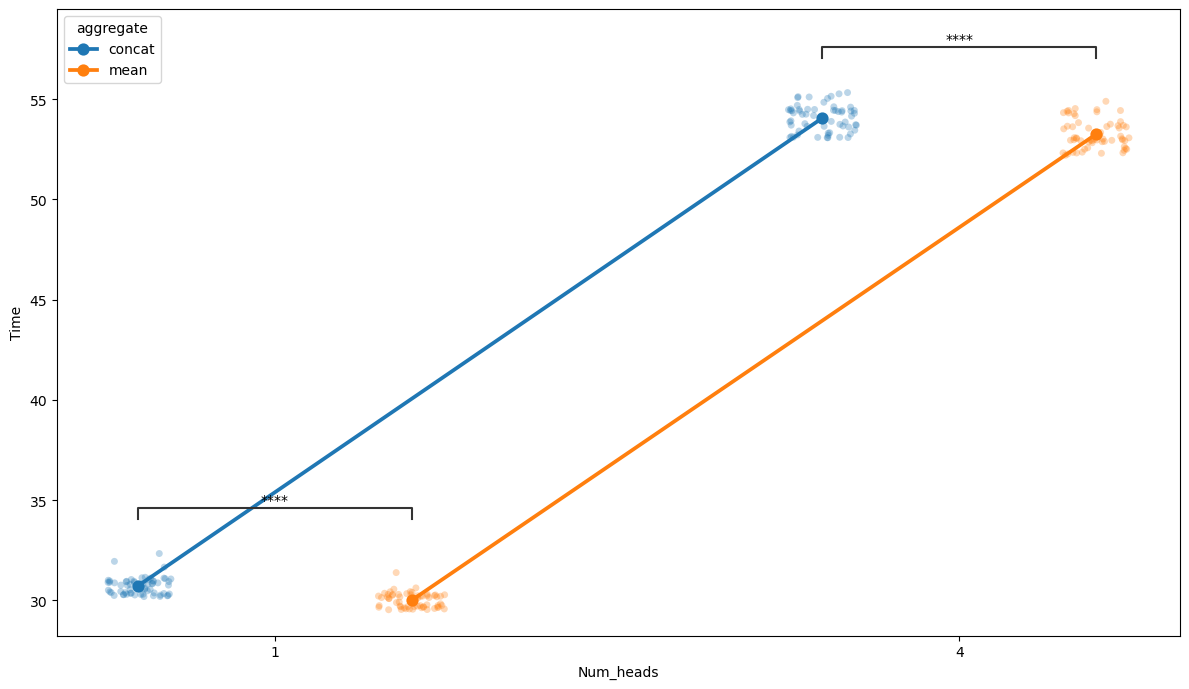

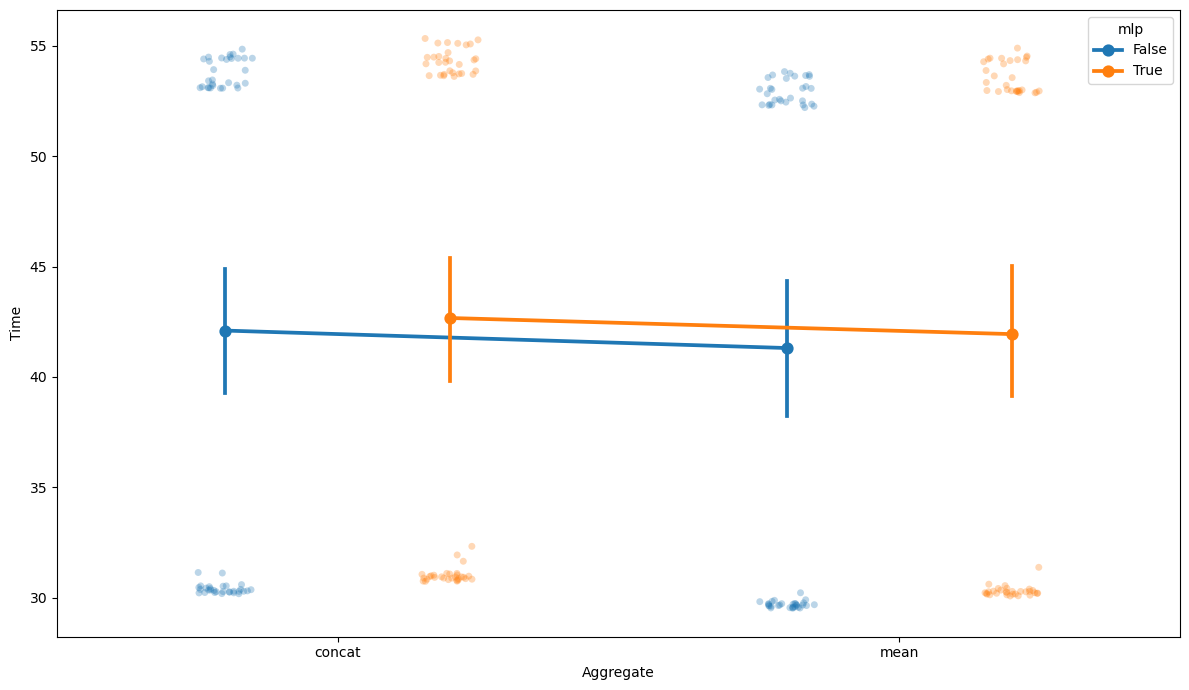

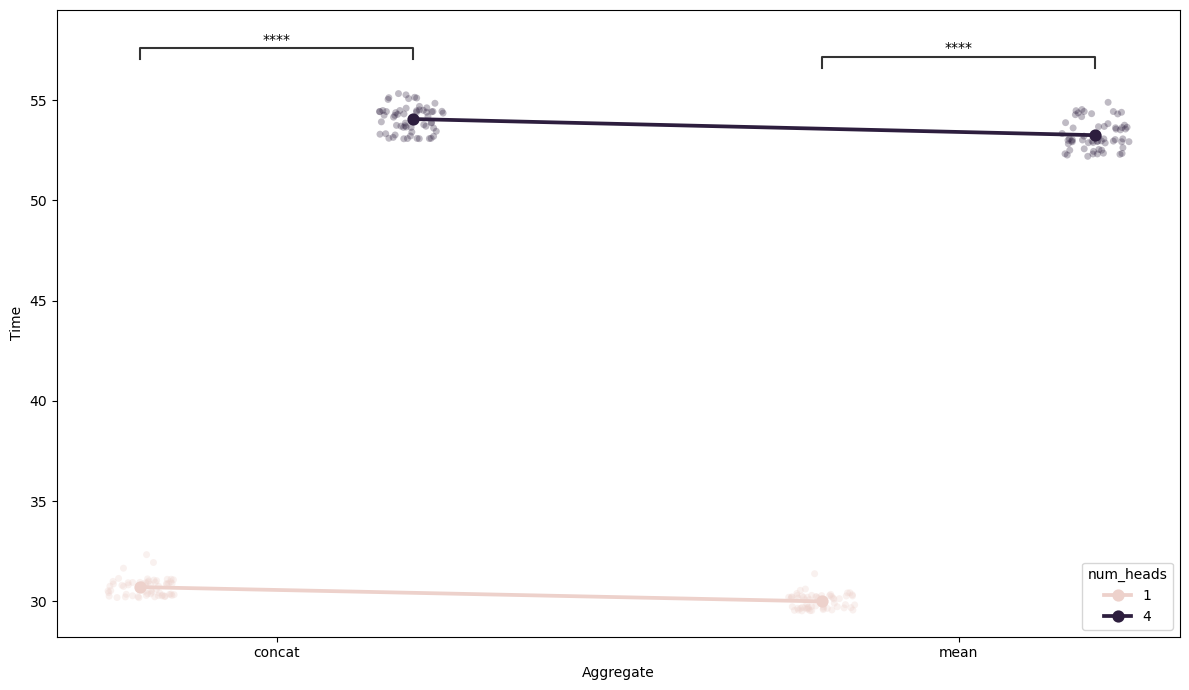

In [4]:
metric_x_point(
    df=test,
    cols=['mlp','num_heads','aggregate'],
    metrics=['accuracy','time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
    hue=True,
)